# Closure-Certified Text-to-Logic Deduction — LOCAL-reader closure vs PoT / self-consistency

**Artifact:** *LOCAL-reader closure vs PoT/self-consistency on NarrativeTime + TDDMan with Prolog traces*
(the headline experiment of the **Closure-Certified Text-to-Logic Deduction Module**).

## What this experiment does

A document is read **span-LOCALLY**: an LLM reads each *constituent edge* of a multi-hop
temporal query (e.g. "is event A before/after/during event C?") in isolation, returning the
set of coarse temporal relations the local text does **not** exclude. Our method, **Mode-A**,
then runs **iterated path-consistency closure** (Mackworth PC-2) over those local reads — with
the *query edge held out* — so the closure must **recover** the deduction-required relation it
never saw directly. The closure runs in the **convex point start-point algebra** (PC-complete,
exact); the five coarse labels `{before, after, simultaneous, includes, is_included}` are exactly
the five convex point relations.

Mode-A is compared, on the **same local reads** and at **matched coverage**, against four baselines:

| arm | what it does |
|---|---|
| **Mode-A (ours)** | PC-2 iterated closure over local path-edge reads; query held out; answers iff it narrows to one relation, else **ABSTAIN** |
| naive | single-pass length-2 intersection (iteration contrast — ties Mode-A on length-2 by theorem) |
| raw | forced single relation from the query edge's own local read |
| Path-of-Thoughts | per-path LLM composition, modal vote, abstain on path disagreement (no cross-path intersection) |
| self-consistency | majority over *k* paraphrase samples of the query local read |

### What runs in this demo (no API key, $0)

The real-text head-to-head needs LLM calls; we **load the pre-computed real-text predictions**
from a curated subset instead. Everything else runs **live and offline**:

1. **Stage-0 closure-correctness tests** — the theorem-grade gate that must pass before any spend.
2. **Synthetic matched-coverage backstop** — the `$0`, fully-powered ($\ge$ hundreds of networks/cell)
   proof that Mode-A beats raw / self-consistency / Path-of-Thoughts and ties naive on length-2,
   *when reads are sound* (recall 0.96).
3. **Worked closure + Prolog trace** — Mode-A narrowing to the correct singleton, and a closure
   **collapse** certifying inconsistency (Mode-B abstain), each emitted as a runnable SWI-Prolog
   program and discharged.
4. **Real-text head-to-head** — per-method selective accuracy & confident-wrong rate on the loaded
   NarrativeTime + TDDMan deduction queries.

> The code below is the **original artifact code** (`engine.py`, `tests.py`, `synth_channel.py`, and the
> statistics / Prolog-discharge functions from `method.py`) split into cells with explanations — not a
> rewrite. The only changes are notebook plumbing (data loading, config knobs, dropping the LLM stages).

In [1]:
# --- Dependencies ---
# Follows the Colab-compatible install pattern: on Colab the pre-installed scientific
# stack is used as-is; locally we install the SAME versions so the env matches Colab.
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy / scipy / matplotlib / pandas are pre-installed on Colab -> install locally only.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'pandas==2.2.2')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
# --- Imports (the artifact's import block + matplotlib/pandas for the demo) ---
import itertools, json, math, os, shutil, subprocess, zlib
from collections import defaultdict, deque
from pathlib import Path

import numpy as np
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt

# numpy 2.0 compatibility shims (harmless if the names already exist)
if not hasattr(np, "alltrue"): np.alltrue = np.all
if not hasattr(np, "sometrue"): np.sometrue = np.any
if not hasattr(np, "product"): np.product = np.prod

In [3]:
# --- Data loading helper (GitHub URL with local fallback, for Colab) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-2/experiment-3/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("Loaded curated real-text subset.")
print("  description :", data["description"][:90], "...")
print("  reader      :", data["reader_primary"])
print("  examples    :", len(data["examples"]),
      "deduction-required query edges (NarrativeTime + TDDMan)")
print("  worked Prolog reference programs:", len(data["worked_examples_prolog_reference"]))

Loaded curated real-text subset.
  description : Curated real-text head-to-head subset from the LOCAL-reader closure experiment (NarrativeT ...
  reader      : google/gemini-3.1-flash-lite
  examples    : 10 deduction-required query edges (NarrativeTime + TDDMan)
  worked Prolog reference programs: 2


## Configuration

All tunable parameters live here. They are set to the **fully-powered original** values
(`N_NET = 600`, `BOOT_B = 2000`); the synthetic backstop is the paper's `$0` deliverable and its
compute is only ~20 s. For an even faster smoke run, drop to `N_NET = 60`, `BOOT_B = 300`.

In [5]:
# ---- Synthetic matched-coverage backstop ($0, NO LLM calls) ----
# Fully-powered original values (compute ~20s); for an even faster smoke run drop to
# N_NET=60, BOOT_B=300.
N_NET   = 600           # networks per synthetic cell         (original: 600)
BOOT_B  = 2000          # bootstrap resamples for CIs         (original: 2000)
SC_K    = 5             # self-consistency paraphrase samples (original: 5)

SYNTH_RECALL = 0.96     # simulated local-reader recall (reads are SOUND)
SYNTH_RHO    = 0.30     # within-document soundness correlation
SEED  = 20260617        # pre-registered seed
ALPHA = 0.05            # CI / significance level

# Synthetic cells: (name, family, params).
#   R = REDUNDANCY (K parallel length-2 paths)  -> naive can match Mode-A's coverage
#   H = HOP / CYCLOMATIC chain (no length-2 query shortcut) -> only iteration (Mode-A) reaches it
SYNTH_CELLS = [
    ("R_redundancy_K4", "R", {"K": 4}),
    ("R_redundancy_K8", "R", {"K": 8}),
    ("H_hop_L4_C2",     "H", {"L": 4, "C": 2}),
    ("H_hop_L6_C3",     "H", {"L": 6, "C": 3}),
]
print(f"N_NET={N_NET}  BOOT_B={BOOT_B}  SC_K={SC_K}  recall={SYNTH_RECALL}  rho={SYNTH_RHO}")

N_NET=600  BOOT_B=2000  SC_K=5  recall=0.96  rho=0.3


## 1. The closure engine (`engine.py`, verbatim)

A self-contained qualitative-constraint-network (QCN) closure engine with two algebras built
**programmatically** (no external table files):

* **POINT** — convex point algebra over event start-points `{<,=,>}`. **PC-complete** → exact
  inconsistency certificate. The only non-convex relation `{<,>}` (`!=`) is *widened* to the
  universe to keep path-consistency complete (every widening is counted).
* **ALLEN** — the 13 Allen interval relations; composition generated by enumerating endpoint
  orderings (sound but PC-incomplete → a *lower bound* on detectable inconsistency).

Closure operators: `close_triangle` (length-2 narrowing), **`pc2_full`** (Mackworth PC-2 to
fixpoint — *our method*), and `naive_single_pass` (one pass, no re-propagation — the baseline).

In [6]:
# ===== engine.py (reused verbatim from the iter-1 frontier pilot) =====
ALLEN_BASE = ["B", "BI", "D", "DI", "O", "OI", "M", "MI", "S", "SI", "F", "FI", "E"]
ALLEN_CONVERSE = {"B": "BI", "BI": "B", "D": "DI", "DI": "D", "O": "OI", "OI": "O",
                  "M": "MI", "MI": "M", "S": "SI", "SI": "S", "F": "FI", "FI": "F", "E": "E"}


def _allen_rel(xs, xe, ys, ye):
    """Atomic Allen relation of interval X=(xs,xe) to Y=(ys,ye) from endpoint ranks."""
    if not (xs < xe and ys < ye):
        return None
    if xs == ys and xe == ye:
        return "E"
    if xe < ys:
        return "B"
    if ye < xs:
        return "BI"
    if xe == ys:
        return "M"
    if ye == xs:
        return "MI"
    if xs == ys:
        return "S" if xe < ye else "SI"
    if xe == ye:
        return "F" if xs > ys else "FI"
    if xs < ys and ye < xe:
        return "DI"
    if ys < xs and xe < ye:
        return "D"
    if xs < ys < xe < ye:
        return "O"
    if ys < xs < ye < xe:
        return "OI"
    return None


def _build_allen_compose():
    """Generate the Allen base x base composition table via endpoint enumeration."""
    comp = {(a, b): set() for a in ALLEN_BASE for b in ALLEN_BASE}
    for asg in itertools.product(range(6), repeat=6):
        As, Ae, Bs, Be, Cs, Ce = asg
        if not (As < Ae and Bs < Be and Cs < Ce):
            continue
        rab = _allen_rel(As, Ae, Bs, Be)
        rbc = _allen_rel(Bs, Be, Cs, Ce)
        rac = _allen_rel(As, Ae, Cs, Ce)
        if rab is None or rbc is None or rac is None:
            continue
        comp[(rab, rbc)].add(rac)
    return {k: frozenset(v) for k, v in comp.items()}


POINT_BASE = ["<", "=", ">"]
POINT_CONVERSE = {"<": ">", "=": "=", ">": "<"}
POINT_COMPOSE = {
    ("=", "="): frozenset({"="}),
    ("<", "="): frozenset({"<"}), ("=", "<"): frozenset({"<"}),
    (">", "="): frozenset({">"}), ("=", ">"): frozenset({">"}),
    ("<", "<"): frozenset({"<"}),
    (">", ">"): frozenset({">"}),
    ("<", ">"): frozenset({"<", "=", ">"}),
    (">", "<"): frozenset({"<", "=", ">"}),
}
POINT_NONCONVEX = frozenset({"<", ">"})  # the only non-convex point relation (`!=`)


class Algebra:
    """A qualitative calculus with relation sets stored as frozensets of base symbols."""

    def __init__(self, name, base, converse, compose_bb, identity, convex_widen=None):
        self.name = name
        self.base = list(base)
        self.universe = frozenset(base)
        self.empty = frozenset()
        self.identity = frozenset(identity)
        self._conv = dict(converse)
        self._comp = dict(compose_bb)
        self._nonconvex = convex_widen

    def converse(self, s):
        return frozenset(self._conv[r] for r in s)

    def compose(self, a, b):
        if not a or not b:
            return self.empty
        out = set()
        for x in a:
            for y in b:
                out |= self._comp[(x, y)]
        return frozenset(out)

    def is_nonconvex(self, s):
        return self._nonconvex is not None and s == self._nonconvex

    def widen(self, s):
        """Return (possibly-widened set, fired?). Only the unique non-convex relation widens."""
        if self._nonconvex is not None and s == self._nonconvex:
            return self.universe, True
        return s, False

    def label(self, s):
        if not s:
            return "EMPTY"
        if s == self.universe:
            return "UNIVERSE"
        return "|".join(r for r in self.base if r in s)


def build_point_algebra():
    return Algebra("POINT", POINT_BASE, POINT_CONVERSE, POINT_COMPOSE,
                   frozenset({"="}), convex_widen=POINT_NONCONVEX)


def build_allen_algebra():
    return Algebra("ALLEN", ALLEN_BASE, ALLEN_CONVERSE, _build_allen_compose(),
                   frozenset({"E"}), convex_widen=None)


def close_triangle(alg, ab, bc, ac):
    """Length-2 path A-B-C narrowing the query edge A-C."""
    n_widen = 0
    path = alg.compose(ab, bc)
    path, w = alg.widen(path)
    n_widen += int(w)
    inter = path & ac
    inter, w = alg.widen(inter)
    n_widen += int(w)
    return {"path": path, "inter": inter, "empty": len(inter) == 0,
            "singleton": len(inter) == 1, "n_widen": n_widen}


class QCN:
    """Constraint network: dense node list, edges = relation-set frozensets."""

    def __init__(self, alg, nodes):
        self.alg = alg
        self.nodes = list(nodes)
        self.n = len(self.nodes)
        self.index = {nd: i for i, nd in enumerate(self.nodes)}
        U = alg.universe
        self.M = [[U] * self.n for _ in range(self.n)]
        for i in range(self.n):
            self.M[i][i] = alg.identity
        self.nbrs = [set() for _ in range(self.n)]

    def set_edge(self, i, j, s):
        if i == j:
            return
        self.M[i][j] = s
        self.M[j][i] = self.alg.converse(s)
        if s != self.alg.universe:
            self.nbrs[i].add(j); self.nbrs[j].add(i)
        else:
            self.nbrs[i].discard(j); self.nbrs[j].discard(i)

    def get(self, i, j):
        return self.M[i][j]

    def known_edges(self):
        U = self.alg.universe
        return [(i, j) for i in range(self.n) for j in range(i + 1, self.n) if self.M[i][j] != U]


def pc2_full(qcn):
    """OUR METHOD: Mackworth PC-2 worklist closure to fixpoint.
    Returns (consistent, n_fired). Empty edge => inconsistent (Mode-B certificate)."""
    alg = qcn.alg
    U = alg.universe
    M = qcn.M
    nbrs = qcn.nbrs
    Q = deque()
    inq = set()
    for (i, j) in qcn.known_edges():
        Q.append((i, j)); inq.add((i, j))
        Q.append((j, i)); inq.add((j, i))
    n_fired = 0

    def enqueue(a, b):
        if (a, b) not in inq:
            inq.add((a, b)); Q.append((a, b))

    while Q:
        i, j = Q.popleft(); inq.discard((i, j))
        rij = M[i][j]
        if rij == U:
            continue
        for k in list(nbrs[j]):
            if k == i:
                continue
            comp = alg.compose(rij, M[j][k])
            new = M[i][k] & comp
            new, _ = alg.widen(new)
            if new != M[i][k]:
                if not new:
                    return False, n_fired
                M[i][k] = new; M[k][i] = alg.converse(new)
                nbrs[i].add(k); nbrs[k].add(i)
                n_fired += 1
                enqueue(i, k); enqueue(k, i)
        for k in list(nbrs[i]):
            if k == j:
                continue
            comp = alg.compose(M[k][i], rij)
            new = M[k][j] & comp
            new, _ = alg.widen(new)
            if new != M[k][j]:
                if not new:
                    return False, n_fired
                M[k][j] = new; M[j][k] = alg.converse(new)
                nbrs[k].add(j); nbrs[j].add(k)
                n_fired += 1
                enqueue(k, j); enqueue(j, k)
    return True, n_fired


def naive_single_pass(qcn, u, v):
    """BASELINE: single pass of length-2 path compositions at the query edge (u,v)."""
    alg = qcn.alg
    U = alg.universe
    M = qcn.M
    R = U
    for w in qcn.nbrs[u]:
        if w in (u, v):
            continue
        if M[w][v] != U:
            R = R & alg.compose(M[u][w], M[w][v])
            R, _ = alg.widen(R)
            if not R:
                return alg.empty
    return R


print("engine.py loaded: POINT + ALLEN algebras, QCN, pc2_full (PC-2), naive_single_pass.")

engine.py loaded: POINT + ALLEN algebras, QCN, pc2_full (PC-2), naive_single_pass.


## 2. Stage-0: blocking closure-correctness tests (`tests.py`, verbatim)

These assertions cross-check the generated composition tables against the verified GQR cells and
exercise the closure operators (length-2 narrowing, cyclic-inconsistency detection, convex widening).
In the full pipeline they **gate all LLM spend**: if any assertion fails, the run aborts before
spending a cent. The closure engine + point-algebra PC-completeness are *theorem-grade*, so a pass
means every closure output is a sound certificate.

In [7]:
# ===== tests.py (reused verbatim) =====
FS = frozenset


def _check(name, got, exp, errs):
    if set(got) != set(exp):
        errs.append(f"{name}: got {sorted(got)} expected {sorted(exp)}")


def closure_tests_pass(verbose=True):
    errs = []
    pt = build_point_algebra()
    al = build_allen_algebra()

    # ---- Allen composition cells verified against GQR ----
    _check("ALLEN <o<  (B o B)", al.compose(FS({"B"}), FS({"B"})), {"B"}, errs)
    _check("ALLEN B o D", al.compose(FS({"B"}), FS({"D"})), {"B", "D", "S", "M", "O"}, errs)
    _check("ALLEN D o DI = universe", al.compose(FS({"D"}), FS({"DI"})), set(al.base), errs)
    _check("ALLEN O o O", al.compose(FS({"O"}), FS({"O"})), {"B", "M", "O"}, errs)
    _check("ALLEN M o M", al.compose(FS({"M"}), FS({"M"})), {"B"}, errs)
    _check("ALLEN M o MI", al.compose(FS({"M"}), FS({"MI"})), {"E", "F", "FI"}, errs)
    _check("ALLEN F o FI", al.compose(FS({"F"}), FS({"FI"})), {"E", "F", "FI"}, errs)
    _check("ALLEN E identity (E o B)", al.compose(FS({"E"}), FS({"B"})), {"B"}, errs)
    _check("ALLEN DI o D (overlap block)", al.compose(FS({"DI"}), FS({"D"})),
           {"E", "D", "DI", "S", "SI", "F", "FI", "O", "OI"}, errs)
    for r in al.base:
        cc = al.converse(al.converse(FS({r})))
        _check(f"ALLEN conv-conv {r}", cc, {r}, errs)
    empty_cells = [(a, b) for a in al.base for b in al.base if not al.compose(FS({a}), FS({b}))]
    if empty_cells:
        errs.append(f"ALLEN has {len(empty_cells)} empty composition cells: {empty_cells[:5]}")

    # ---- Point algebra cells (GQR point.comp) ----
    _check("POINT < o <", pt.compose(FS({"<"}), FS({"<"})), {"<"}, errs)
    _check("POINT > o >", pt.compose(FS({">"}), FS({">"})), {">"}, errs)
    _check("POINT < o > = universe", pt.compose(FS({"<"}), FS({">"})), {"<", "=", ">"}, errs)
    _check("POINT > o < = universe", pt.compose(FS({">"}), FS({"<"})), {"<", "=", ">"}, errs)
    _check("POINT = identity (= o <)", pt.compose(FS({"="}), FS({"<"})), {"<"}, errs)
    w, fired = pt.widen(FS({"<", ">"}))
    if not (set(w) == {"<", "=", ">"} and fired):
        errs.append(f"POINT widen({{<,>}}) -> {sorted(w)} fired={fired} (expected universe, True)")
    w2, fired2 = pt.widen(FS({"<", "="}))
    if not (set(w2) == {"<", "="} and not fired2):
        errs.append("POINT widen({<,=}) wrongly fired (convex set must not widen)")

    # ---- close_triangle: four hand-constructed scenarios ----
    r = close_triangle(pt, FS({"<"}), FS({"<"}), FS({"<", "=", ">"}))
    if not (set(r["path"]) == {"<"} and set(r["inter"]) == {"<"} and r["singleton"] and not r["empty"]):
        errs.append(f"close_triangle (a) point b&b: {r}")
    r = close_triangle(pt, FS({"<"}), FS({">"}), FS({"<", "=", ">"}))
    if not (set(r["path"]) == {"<", "=", ">"} and not r["empty"] and not r["singleton"]):
        errs.append(f"close_triangle (b) point b&a: {r}")
    r = close_triangle(pt, FS({"<"}), FS({"<"}), FS({">"}))
    if not (r["empty"] and len(r["inter"]) == 0):
        errs.append(f"close_triangle (c) inconsistent collapse: {r}")
    r = close_triangle(al, FS({"D"}), FS({"D"}), set(al.base))
    if not (set(r["path"]) == {"D"} and set(r["inter"]) == {"D"} and r["singleton"]):
        errs.append(f"close_triangle (d) allen D&D: {r}")

    # ---- pc2_full / naive on length-2 vs cyclic networks ----
    q = QCN(pt, ["A", "B", "C"])
    q.set_edge(0, 1, FS({"<"})); q.set_edge(1, 2, FS({"<"}))
    naive = naive_single_pass(q, 0, 2)
    ok, _ = pc2_full(q)
    if not (set(naive) == {"<"} and ok and set(q.get(0, 2)) == {"<"}):
        errs.append(f"PC vs naive length-2: naive={sorted(naive)} pc_edge={sorted(q.get(0,2))} ok={ok}")
    q2 = QCN(pt, ["A", "B", "C"])
    q2.set_edge(0, 1, FS({"<"})); q2.set_edge(1, 2, FS({"<"})); q2.set_edge(2, 0, FS({"<"}))
    ok2, _ = pc2_full(q2)
    if ok2:
        errs.append("pc2_full failed to detect cyclic inconsistency A<B<C<A")

    res = {"n_errors": len(errs), "errors": errs, "allen_compose_cells": len(al.base) ** 2}
    if verbose:
        if errs:
            print("CLOSURE TESTS FAILED:")
            for e in errs:
                print("  -", e)
        else:
            print("ALL CLOSURE TESTS PASSED "
                  f"(Allen {len(al.base)}^2={len(al.base)**2} cells generated & cross-checked).")
    return (len(errs) == 0), res


ok, tres = closure_tests_pass(verbose=True)
assert ok, "Closure tests must pass before any downstream metrics are valid."

ALL CLOSURE TESTS PASSED (Allen 13^2=169 cells generated & cross-checked).


## 3. Synthetic matched-coverage backstop (`synth_channel.py`, verbatim)

The `$0`, fully-powered backstop. It builds temporal networks that are **consistent by
construction**, then reads their edges through a **simulated channel** with exact knobs
(recall, breadth, within-document correlation `rho`). Two families:

* **R (redundancy)** — `K` parallel length-2 paths `i → mₖ → j`; *every* length-2 composition
  already pins the gold relation, so the naive single-pass baseline can match Mode-A's coverage.
* **H (hop / cyclomatic)** — a length-`L` chain with `C` chords and **no length-2 query shortcut**,
  so only iterated closure (Mode-A) can reach the query — naive/PoT structurally cannot.

The same five methods compared on real text (Mode-A, naive, raw, self-consistency, Path-of-Thoughts)
are run on each network. With recall ≈ 0.96 the reads are **sound**, isolating the *mechanism*.

In [8]:
# ===== synth_channel.py (reused verbatim from iter-1 exp-2; matched-coverage harness new) =====
# 3-bit masks: LT=1, EQ=2, GT=4, U=7, EMPTY=0.
LT, EQ, GT, U, EMPTY = 1, 2, 4, 7, 0
BASE_BITS = (LT, EQ, GT)
CONVEX = (LT, EQ, GT, LT | EQ, EQ | GT, U)
NONCONVEX = LT | GT
REL_NAME = {0: "EMPTY", 1: "<", 2: "=", 4: ">", 3: "<=", 6: ">=", 7: "?", 5: "<>"}

BASE_COMP = {
    (LT, LT): LT, (LT, EQ): LT, (LT, GT): U,
    (EQ, LT): LT, (EQ, EQ): EQ, (EQ, GT): GT,
    (GT, LT): U,  (GT, EQ): GT, (GT, GT): GT,
}
CONV_BASE = {LT: GT, EQ: EQ, GT: LT}


def _build_tables():
    comp = [[0] * 8 for _ in range(8)]
    conv = [0] * 8
    for R in range(8):
        m = 0
        for a in BASE_BITS:
            if R & a:
                m |= CONV_BASE[a]
        conv[R] = m
        for S in range(8):
            mm = 0
            for a in BASE_BITS:
                if R & a:
                    for b in BASE_BITS:
                        if S & b:
                            mm |= BASE_COMP[(a, b)]
            comp[R][S] = mm
    return comp, conv


COMP, CONV = _build_tables()


def popcount(x):
    return bin(x).count("1")


def self_verify_point_algebra():
    assert COMP[LT][LT] == LT
    assert COMP[LT][EQ] == LT
    assert COMP[LT][GT] == U
    assert COMP[EQ][GT] == GT
    assert COMP[GT][LT] == U
    assert COMP[GT][GT] == GT
    assert CONV[LT] == GT and CONV[GT] == LT and CONV[EQ] == EQ
    assert CONV[LT | EQ] == EQ | GT
    assert (LT | EQ) & (EQ | GT) == EQ
    for R in CONVEX:
        assert COMP[EQ][R] == R and COMP[R][EQ] == R
    for R in CONVEX:
        for S in CONVEX:
            assert COMP[R][S] != NONCONVEX
            assert (R & S) != NONCONVEX
    rng = np.random.default_rng(0)
    for _ in range(2000):
        a, b, c = (int(rng.choice(CONVEX)) for _ in range(3))
        assert COMP[COMP[a][b]][c] == COMP[a][COMP[b][c]]


class Net:
    __slots__ = ("n", "edges", "gold", "query", "gold_query")

    def __init__(self, n, edges, gold, query, gold_query):
        self.n = n
        self.edges = edges
        self.gold = gold
        self.query = query
        self.gold_query = gold_query


def _base_from_times(ta, tb):
    if ta < tb:
        return LT
    if ta > tb:
        return GT
    return EQ


def gen_family_R(K, rng):
    """REDUNDANCY family: K parallel length-2 paths i -> m_k -> j."""
    i, j = 0, 1
    t = {i: 0.0, j: 10.0}
    edges = []
    gold = {}
    for k in range(K):
        m = 2 + k
        t[m] = float(rng.uniform(1.0, 9.0))
        edges.append((i, m))
        edges.append((m, j))
    for (a, b) in edges:
        gold[(a, b)] = _base_from_times(t[a], t[b])
    n = 2 + K
    query = (i, j)
    gold_query = _base_from_times(t[i], t[j])
    gold[query] = gold_query
    return Net(n, edges, gold, query, gold_query)


def gen_family_H(L, C, rng):
    """HOP/CYCLOMATIC family: chain length L + C interior chords; NO direct (i,j) edge."""
    i, j = 0, L
    t = {node: float(node) for node in range(L + 1)}
    edges = [(n_, n_ + 1) for n_ in range(L)]
    interior = list(range(1, L))
    cand = [(a, b) for ai, a in enumerate(interior) for b in interior[ai + 1:]
            if b - a >= 2]
    rng.shuffle(cand)
    added = 0
    for (a, b) in cand:
        if added >= C:
            break
        if (a, b) in edges or (b, a) in edges:
            continue
        edges.append((a, b))
        added += 1
    gold = {}
    for (a, b) in edges:
        gold[(a, b)] = _base_from_times(t[a], t[b])
    query = (i, j)
    gold_query = _base_from_times(t[i], t[j])
    gold[query] = gold_query
    cyclo = len(edges) - (L + 1) + 1
    return Net(L + 1, edges, gold, query, gold_query), cyclo


_SOUND = {
    LT: ([LT, LT | EQ, U]),
    EQ: ([EQ, LT | EQ, EQ | GT, U]),
    GT: ([GT, EQ | GT, U]),
}
_UNSOUND = {
    LT: [EQ, GT, EQ | GT],
    EQ: [LT, GT],
    GT: [LT, EQ, LT | EQ],
}


def _sound_weights(g, breadth):
    ps, pt, pu = breadth["p_singleton"], breadth["p_two"], breadth["p_univ"]
    if g == EQ:
        w = np.array([ps, pt / 2.0, pt / 2.0, pu], dtype=float)
    else:
        w = np.array([ps, pt, pu], dtype=float)
    s = w.sum()
    return w / s if s > 0 else np.ones_like(w) / len(w)


class ReadResult:
    __slots__ = ("rel", "sound", "conf", "edges", "bite_lost", "kept")

    def __init__(self, rel, sound, conf, edges, bite_lost, kept):
        self.rel = rel
        self.sound = sound
        self.conf = conf
        self.edges = edges
        self.bite_lost = bite_lost
        self.kept = kept


def read_network(net, r, rho, breadth, rng, gate=False, gate_drop=0.0, edges=None):
    """Read a chosen edge list (default net.edges) through the noisy channel."""
    qn = norm.ppf(min(max(r, 1e-9), 1.0 - 1e-9))
    u_latent = float(rng.standard_normal())
    sqrt_rho = math.sqrt(rho)
    sqrt_1mrho = math.sqrt(1.0 - rho)
    rel, sound, conf = {}, {}, {}
    bite_lost = 0
    use_edges = list(net.edges if edges is None else edges)
    for (a, b) in use_edges:
        g = net.gold[(a, b)]
        v = float(rng.standard_normal())
        z = sqrt_rho * u_latent + sqrt_1mrho * v
        is_sound = (z <= qn)
        c = float(norm.cdf(-z) + 0.01 * rng.standard_normal())
        if is_sound:
            opts = _SOUND[g]
            w = _sound_weights(g, breadth)
            s_e = int(rng.choice(opts, p=w))
        else:
            opts = _UNSOUND[g]
            s_e = int(rng.choice(opts))
        if s_e == NONCONVEX:
            s_e = U
            bite_lost += 1
        rel[(a, b)] = s_e
        rel[(b, a)] = CONV[s_e]
        sound[(a, b)] = bool(is_sound)
        conf[(a, b)] = c
    kept = {e: True for e in use_edges}
    if gate and use_edges:
        confs = np.array([conf[e] for e in use_edges])
        ndrop = int(math.floor(gate_drop * len(use_edges)))
        if ndrop > 0:
            drop_idx = np.argsort(confs)[:ndrop]
            for di in drop_idx:
                kept[use_edges[int(di)]] = False
    return ReadResult(rel, sound, conf, use_edges, bite_lost, kept)


def _matrix_from_read(net, rd):
    n = net.n
    M = [[U] * n for _ in range(n)]
    for x in range(n):
        M[x][x] = EQ
    for (a, b) in rd.edges:
        if not rd.kept[(a, b)]:
            continue
        M[a][b] = rd.rel[(a, b)]
        M[b][a] = rd.rel[(b, a)]
    return M


def closure_FULL(M, n):
    """Iterated path-consistency (PC-2 / Mackworth). VERBATIM."""
    changed = True
    while changed:
        changed = False
        for k in range(n):
            Mk = M[k]
            for i in range(n):
                if i == k:
                    continue
                rik = M[i][k]
                if rik == U:
                    continue
                Mi = M[i]
                comp_row = COMP[rik]
                for j in range(n):
                    if j == i or j == k:
                        continue
                    rkj = Mk[j]
                    if rkj == U:
                        continue
                    new = Mi[j] & comp_row[rkj]
                    if new != Mi[j]:
                        Mi[j] = new
                        M[j][i] = CONV[new]
                        if new == EMPTY:
                            return "COLLAPSE", M
                        changed = True
    return "OK", M


def closure_NAIVE(rd, n, query):
    """Single pass, NO fixpoint over directly-read length-2 paths. VERBATIM."""
    i, j = query
    res = rd.rel.get((i, j), U) if rd.kept.get((i, j), False) else U
    for k in range(n):
        if k == i or k == j:
            continue
        a = rd.rel.get((i, k))
        b = rd.rel.get((k, j))
        ka = rd.kept.get((i, k), False) or rd.kept.get((k, i), False)
        kb = rd.kept.get((k, j), False) or rd.kept.get((j, k), False)
        if a is not None and b is not None and ka and kb:
            res &= COMP[a][b]
    return res


def _forced_single(relset, rng):
    """Commit a (possibly disjunctive) read to ONE base relation (the LLM 'guessing')."""
    members = [b for b in BASE_BITS if relset & b]
    if not members:
        members = list(BASE_BITS)
    return int(rng.choice(members))


def _min_path_conf(net, rd):
    cs = [rd.conf[e] for e in net.edges if rd.kept.get(e, False)]
    return float(min(cs)) if cs else 0.0


def run_methods_on_net(net, r, rho, breadth, sc_k, rng):
    """Return {method: (answered, correct|None, conf)} for ONE network."""
    gq = net.gold_query
    rd = read_network(net, r, rho, breadth, rng)            # path-edge reads
    M = _matrix_from_read(net, rd)
    i, j = net.query

    # --- Mode-A FULL closure (our method): query held at U ---
    status, Mc = closure_FULL([row[:] for row in M], net.n)
    if status == "COLLAPSE":
        modeA = (False, None, _min_path_conf(net, rd))      # abstain (inconsistency)
    else:
        rset = Mc[i][j]
        if popcount(rset) == 1:
            modeA = (True, int(rset == gq), _min_path_conf(net, rd))
        else:
            modeA = (False, None, _min_path_conf(net, rd))  # disjunction -> abstain

    # --- NAIVE single-pass ---
    nres = closure_NAIVE(rd, net.n, net.query)
    if nres != EMPTY and popcount(nres) == 1:
        naive = (True, int(nres == gq), _min_path_conf(net, rd))
    else:
        naive = (False, None, _min_path_conf(net, rd))

    # --- direct query-edge reads (for RAW + SC), same channel ---
    qnet = Net(net.n, [net.query], {net.query: gq, (j, i): CONV[gq]}, net.query, gq)
    q_reads = []
    for _ in range(max(1, sc_k)):
        rq = read_network(qnet, r, rho, breadth, rng, edges=[net.query])
        q_reads.append((rq.rel[net.query], rq.conf[net.query]))
    raw_set, raw_conf = q_reads[0]
    raw_pred = _forced_single(raw_set, rng)
    raw = (True, int(raw_pred == gq), float(raw_conf))
    votes = [_forced_single(s, rng) for (s, _) in q_reads]
    counts = {b: votes.count(b) for b in set(votes)}
    top = max(counts, key=counts.get)
    margin = counts[top] / len(votes)
    sc = (True, int(top == gq), float(margin))

    # --- PATH-OF-THOUGHTS analog: per length-2 path compose, modal vote, abstain on disagreement ---
    path_preds = []
    path_confs = []
    for k in range(net.n):
        if k in (i, j):
            continue
        a = rd.rel.get((i, k)); b = rd.rel.get((k, j))
        ka = rd.kept.get((i, k), False); kb = rd.kept.get((k, j), False)
        if a is not None and b is not None and ka and kb:
            comp = COMP[a][b]
            path_preds.append(_forced_single(comp, rng))     # reason this path INDEPENDENTLY
            path_confs.append(min(rd.conf[(i, k)], rd.conf[(k, j)]))
    if not path_preds:
        pot = (False, None, 0.0)
    else:
        pcounts = {b: path_preds.count(b) for b in set(path_preds)}
        ptop = max(pcounts, key=pcounts.get)
        agree = pcounts[ptop] / len(path_preds)
        if len(pcounts) > 1 and agree < 1.0 - 1e-9 and len(path_preds) > 1:
            answered = agree >= 0.5
        else:
            answered = True
        pot = (answered, (int(ptop == gq) if answered else None),
               float(agree * (sum(path_confs) / len(path_confs))))
    return {"modeA_full": modeA, "naive": naive, "raw": raw, "sc": sc, "pot": pot}


def simulate_matched_coverage(family, params, n_net, r, rho, breadth, sc_k, seed):
    """Run n_net networks; return per-method lists of (answered, correct, conf, net_id)."""
    rng = np.random.default_rng(seed)
    rows = {m: [] for m in ("modeA_full", "naive", "raw", "sc", "pot")}
    for ni in range(n_net):
        if family == "R":
            net = gen_family_R(params["K"], rng)
        else:
            net, _ = gen_family_H(params["L"], params.get("C", 0), rng)
        res = run_methods_on_net(net, r, rho, breadth, sc_k, rng)
        for m, (ans, corr, conf) in res.items():
            rows[m].append({"answered": bool(ans), "correct": corr,
                            "conf": float(conf), "net": ni})
    return rows


self_verify_point_algebra()
print("synth_channel.py loaded and point-algebra self-verify PASSED.")

synth_channel.py loaded and point-algebra self-verify PASSED.


## 4. Matched-coverage statistics (`method.py`, verbatim)

To compare methods **fairly**, we never compare raw accuracies — methods abstain at different
rates. Instead we build a **risk–coverage curve** (sort each method's answers by confidence; plot
selective accuracy vs the fraction answered) and read off the **gap** = Mode-A's selective accuracy
at its natural coverage minus a baseline's accuracy *at the same coverage*. CIs come from a
**document-clustered paired bootstrap**. When a baseline structurally cannot reach Mode-A's
coverage (the H family), it is flagged `base_unreachable`.

In [9]:
# ===== statistics (verbatim from method.py) =====
def _curve(records):
    """Risk-coverage curve: sorted (coverage, selective_acc) + natural coverage + selective acc."""
    n = len(records)
    ans = [(r["conf"], r["correct"]) for r in records
           if r["answered"] and r["correct"] is not None]
    if n == 0:
        return [], 0.0, float("nan")
    ans.sort(key=lambda x: -x[0])
    pts = []
    cum = 0
    for k, (_, corr) in enumerate(ans, start=1):
        cum += corr
        pts.append((k / n, cum / k))
    nat_cov = len(ans) / n
    nat_acc = (cum / len(ans)) if ans else float("nan")
    return pts, nat_cov, nat_acc


def _acc_at_coverage(pts, target):
    """Interpolate selective accuracy at a target coverage. NaN if target exceeds max coverage."""
    if not pts:
        return float("nan")
    if target <= pts[0][0]:
        return pts[0][1]
    if target > pts[-1][0] + 1e-9:
        return float("nan")
    for i in range(1, len(pts)):
        c0, a0 = pts[i - 1]
        c1, a1 = pts[i]
        if c0 <= target <= c1:
            if c1 == c0:
                return a1
            w = (target - c0) / (c1 - c0)
            return a0 + w * (a1 - a0)
    return pts[-1][1]


def clustered_bootstrap_ci(doc_to_vals, B=BOOT_B, seed=SEED, alpha=ALPHA):
    docs = [d for d, v in doc_to_vals.items() if v]
    if len(docs) < 2:
        allv = [x for v in doc_to_vals.values() for x in v]
        m = float(np.mean(allv)) if allv else float("nan")
        return [m, m]
    rng = np.random.default_rng(seed)
    arrs = {d: np.array(doc_to_vals[d], dtype=float) for d in docs}
    nd = len(docs)
    means = []
    for _ in range(B):
        pick = rng.integers(0, nd, nd)
        vals = np.concatenate([arrs[docs[i]] for i in pick])
        means.append(vals.mean())
    lo, hi = np.quantile(means, [alpha / 2, 1 - alpha / 2])
    return [float(lo), float(hi)]


def matched_coverage_gap(method_recs, base_recs, by_doc_method, by_doc_base, seed=SEED, B=BOOT_B):
    """Gap = method selective_acc at method's natural coverage MINUS baseline acc at SAME coverage."""
    m_pts, m_cov, m_acc = _curve(method_recs)
    b_pts, b_cov, b_acc_nat = _curve(base_recs)
    base_acc = _acc_at_coverage(b_pts, m_cov)
    point_gap = m_acc - base_acc if (m_acc == m_acc and base_acc == base_acc) else float("nan")
    base_unreachable = (b_cov + 1e-9 < m_cov)
    docs = sorted(set(by_doc_method) | set(by_doc_base))
    rng = np.random.default_rng(seed)
    gaps = []
    nd = len(docs)
    for _ in range(B):
        pick = [docs[i] for i in rng.integers(0, nd, nd)]
        mrec = [r for d in pick for r in by_doc_method.get(d, [])]
        brec = [r for d in pick for r in by_doc_base.get(d, [])]
        mp, mc, ma = _curve(mrec)
        bp, _, _ = _curve(brec)
        ba = _acc_at_coverage(bp, mc)
        if ma == ma and ba == ba:
            gaps.append(ma - ba)
    if not gaps:
        return {"gap": point_gap, "ci95": [float("nan"), float("nan")],
                "matched_coverage": m_cov, "method_acc": m_acc, "base_acc": base_acc,
                "base_max_coverage": b_cov, "base_unreachable": bool(base_unreachable),
                "boot_p_gap_le_0": (0.0 if base_unreachable else 1.0)}
    lo, hi = np.quantile(gaps, [ALPHA / 2, 1 - ALPHA / 2])
    p_gt0 = float(np.mean([g > 0 for g in gaps]))
    return {"gap": point_gap, "ci95": [float(lo), float(hi)], "boot_p_gap_le_0": 1 - p_gt0,
            "matched_coverage": m_cov, "method_acc": m_acc, "base_acc": base_acc,
            "base_max_coverage": b_cov, "base_unreachable": bool(base_unreachable),
            "n_boot": len(gaps)}


def auc_rc(pts, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    vals = [_acc_at_coverage(pts, c) for c in grid]
    vals = [v for v in vals if v == v]
    return float(np.mean(vals)) if vals else float("nan")


print("statistics loaded: _curve, matched_coverage_gap (doc-clustered paired bootstrap), auc_rc.")

statistics loaded: _curve, matched_coverage_gap (doc-clustered paired bootstrap), auc_rc.


## 5. Run the synthetic backstop — the `$0` mechanism proof

Each cell runs `N_NET` networks and computes Mode-A's selective-accuracy **gap** at matched
coverage versus every baseline. Expected pattern (the paper's headline mechanism claim):

* **R (redundancy):** Mode-A ≈ naive (length-2 ties by theorem) and **beats** raw / self-consistency.
* **H (hop):** naive / Path-of-Thoughts are **structurally unreachable** (`base_unreachable=True`) —
  only iterated closure reaches the query — and Mode-A beats raw / self-consistency.

In [10]:
def SC_cell_seed(name):
    return (SEED + zlib.crc32(name.encode())) % (2 ** 31)


def synthetic_matched_coverage():
    self_verify_point_algebra()
    breadth = {"p_singleton": 0.6, "p_two": 0.3, "p_univ": 0.1}
    r = SYNTH_RECALL
    rho = SYNTH_RHO
    out = {}
    for name, fam, params in SYNTH_CELLS:
        rows = simulate_matched_coverage(fam, params, n_net=N_NET, r=r, rho=rho,
                                         breadth=breadth, sc_k=SC_K, seed=SC_cell_seed(name))
        by_doc = {m: defaultdict(list) for m in rows}
        recs = {m: [] for m in rows}
        for m, lst in rows.items():
            for x in lst:
                rec = {"answered": x["answered"], "correct": x["correct"], "conf": x["conf"]}
                recs[m].append(rec)
                by_doc[m][x["net"]].append(rec)
        modeA = recs["modeA_full"]
        comp = {}
        for base in ("raw", "sc", "pot", "naive"):
            comp[base] = matched_coverage_gap(modeA, recs[base], by_doc["modeA_full"],
                                              by_doc[base], seed=SC_cell_seed(name + base))
        _, m_cov, m_acc = _curve(modeA)
        out[name] = {"family": fam, "params": params, "recall": r, "rho": rho,
                     "modeA_natural_coverage": m_cov, "modeA_selective_acc": m_acc,
                     "vs_baselines": comp, "n_networks": N_NET}
    return out


synth = synthetic_matched_coverage()

print(f"Synthetic matched-coverage backstop  (recall={SYNTH_RECALL}, {N_NET} networks/cell, $0)\n")
hdr = f"{'cell':18s} {'modeA_cov':>9s} {'modeA_acc':>9s} | " \
      f"{'vs raw':>8s} {'vs sc':>8s} {'vs pot':>8s} {'vs naive':>9s}"
print(hdr); print("-" * len(hdr))
for name, s in synth.items():
    g = s["vs_baselines"]
    def gp(b):
        x = g[b]["gap"]
        tag = "*" if g[b].get("base_unreachable") else " "
        return ("nan" if x != x else f"{x:+.3f}") + tag
    print(f"{name:18s} {s['modeA_natural_coverage']:9.2f} {s['modeA_selective_acc']:9.3f} | "
          f"{gp('raw'):>8s} {gp('sc'):>8s} {gp('pot'):>8s} {gp('naive'):>9s}")
print("\n  (gap = Mode-A selective acc - baseline acc at MATCHED coverage; "
      "* = baseline structurally cannot reach Mode-A's coverage)")

Synthetic matched-coverage backstop  (recall=0.96, 600 networks/cell, $0)

cell               modeA_cov modeA_acc |   vs raw    vs sc   vs pot  vs naive
-----------------------------------------------------------------------------
R_redundancy_K4         0.97     1.000 |  +0.219   +0.043   +0.021    +0.000 
R_redundancy_K8         0.96     1.000 |  +0.260   +0.064   +0.002    +0.000 
H_hop_L4_C2             0.71     1.000 |  +0.211   +0.026      nan*      nan*
H_hop_L6_C3             0.69     1.000 |  +0.212   +0.017      nan*      nan*

  (gap = Mode-A selective acc - baseline acc at MATCHED coverage; * = baseline structurally cannot reach Mode-A's coverage)


## 6. Worked closure + human-auditable Prolog trace

The audit deliverable: each Mode-A decision is emitted as a **runnable SWI-Prolog program** over
the convex point composition table, and discharged. The query relation is the **intersection of
every length-2 path composition** (path-consistency narrowing); an empty intersection certifies
inconsistency → **Mode-B abstain**. We show two cases and **cross-check** the Prolog derivation
against the closure engine's `pc2_full` result:

1. **Mode-A narrows to the correct singleton** — `A before B`, `B before C` ⇒ recover `A before C`.
2. **Closure collapse → Mode-B abstain** — adding a conflicting path makes the intersection empty.

(SWI-Prolog isn't installed in this environment, so the discharge falls back to the self-contained
Python resolution — the engine results are Prolog-independent.)

In [11]:
# ===== Prolog discharge + coarse<->point helpers (verbatim from method.py / corpora.py) =====
PT = build_point_algebra()
COARSE_LABELS = ["before", "after", "simultaneous", "includes", "is_included"]
COARSE_TO_POINT = {
    "before": frozenset({"<"}), "after": frozenset({">"}),
    "simultaneous": frozenset({"="}),
    "includes": frozenset({"<", "="}), "is_included": frozenset({"=", ">"}),
}
POINT_SET_TO_COARSE = {
    frozenset({"<"}): "before", frozenset({">"}): "after",
    frozenset({"="}): "simultaneous", frozenset({"<", "="}): "includes",
    frozenset({"=", ">"}): "is_included",
}
COARSE_CONVERSE = {"before": "after", "after": "before", "simultaneous": "simultaneous",
                   "includes": "is_included", "is_included": "includes"}

POINT_COMP_FACTS = [
    ("lt", "lt", "lt"), ("lt", "eq", "lt"), ("eq", "lt", "lt"), ("eq", "eq", "eq"),
    ("eq", "gt", "gt"), ("gt", "eq", "gt"), ("gt", "gt", "gt"),
]
PT_SYM = {"<": "lt", "=": "eq", ">": "gt"}
SYM_PT = {"lt": "<", "eq": "=", "gt": ">"}
PT_CONV_SYM = {"lt": "gt", "gt": "lt", "eq": "eq"}


def coarse_to_point(coarse_set, underdet):
    """Union of coarse labels -> convex point set. Empty/underdet -> universe."""
    if underdet or not coarse_set:
        return PT.universe
    out = set()
    for c in coarse_set:
        out |= set(COARSE_TO_POINT[c])
    pset = frozenset(out) if out else PT.universe
    pset, _ = PT.widen(pset)
    return pset


def orient_point(pset, stored_uv, want_uv):
    if stored_uv == want_uv:
        return pset
    if (stored_uv[1], stored_uv[0]) == want_uv:
        return PT.converse(pset)
    return pset


def point_to_coarse(R):
    return POINT_SET_TO_COARSE.get(frozenset(R))


def emit_prolog(q, emitted, outpath, engine_relation=None):
    """Emit a runnable SWI-Prolog program for the closed query subgraph and discharge the
    held-out query edge (swipl if available, else self-contained python resolution)."""
    docid, qx, qy = q["docid"], q["qx"], q["qy"]

    def nid(x):
        return "e_" + "".join(ch if ch.isalnum() else "_" for ch in str(x))

    facts = []
    seen = set()
    for (a, b) in q["path_edges"]:
        key = (docid,) + tuple(sorted((a, b)))
        em = emitted.get(key)
        if em is None:
            continue
        pset = orient_point(em["point_set"], em["stored_uv"], (a, b))
        if len(pset) != 1:
            continue
        sym = PT_SYM[next(iter(pset))]
        na, nb = nid(a), nid(b)
        if (na, nb) not in seen:
            facts.append((na, nb, sym)); seen.add((na, nb))
        if (nb, na) not in seen:
            facts.append((nb, na, PT_CONV_SYM[sym])); seen.add((nb, na))

    lines = [
        "% Closure-certified temporal deduction -- auto-generated trace program.",
        "% Convex point start-point algebra over event start points {lt,eq,gt}.",
        "% The query relation is the INTERSECTION of all length-2 path compositions",
        "% (path-consistency narrowing); an empty intersection certifies inconsistency.",
        ":- discontiguous rel/3.", "",
        "% --- composition table (Vilain-Kautz convex point algebra) ---",
    ]
    for (a, b, c) in POINT_COMP_FACTS:
        lines.append(f"comp({a},{b},{c}).")
    lines += ["", "% --- read facts (LOCAL LLM reads; both directions via converse) ---"]
    for (a, b, s) in facts:
        lines.append(f"rel({a},{b},{s}).")
    lines += ["",
              f"% --- query: intersect every {nid(qx)}->M->{nid(qy)} composition ---",
              f"path_comp({nid(qx)},{nid(qy)},R) :- rel({nid(qx)},M,R1), "
              f"rel(M,{nid(qy)},R2), comp(R1,R2,R).",
              "main :- ( setof(R, path_comp(%s,%s,R), Rs) -> "
              "format('PATHS: ~w~n',[Rs]) ; write('PATHS: none'), nl ), halt."
              % (nid(qx), nid(qy)),
              "", ":- initialization(main)."]
    prog = "\n".join(lines) + "\n"
    outpath.write_text(prog)

    comp = {(a, b): c for (a, b, c) in POINT_COMP_FACTS}
    adj = defaultdict(list)
    for (uu, vv, s) in facts:
        adj[uu].append((vv, s))
    path_results = []
    for (mid, r1) in adj.get(nid(qx), []):
        for (v2, r2) in adj.get(mid, []):
            if v2 == nid(qy) and (r1, r2) in comp:
                path_results.append(comp[(r1, r2)])
    if not path_results:
        derived_set = set()
        derived = "underdetermined (no length-2 path among singleton reads)"
    else:
        inter = set(SYM_PT)
        for s in path_results:
            inter &= {s}
        derived_set = inter
        derived = next(iter(inter)) if len(inter) == 1 else (
            "EMPTY (inconsistent -> Mode-B abstain)" if not inter else "|".join(sorted(inter)))
    method = "python-checked (swipl-unavailable)"
    if shutil.which("swipl"):
        try:
            rr = subprocess.run(["swipl", "-q", str(outpath)], capture_output=True,
                                text=True, timeout=30)
            method = "swipl: " + (rr.stdout or "").strip().replace("\n", " ")
        except Exception as e:
            method = f"swipl-error:{e}; python-checked"

    gold_sym = "|".join(PT_SYM[s] for s in sorted(COARSE_TO_POINT[q["gold"]]))
    derived_coarse = point_to_coarse(frozenset(SYM_PT[s] for s in derived_set)) if derived_set else None
    return {"prolog_path": str(outpath), "discharge_method": method,
            "derived_point": derived, "derived_coarse": derived_coarse,
            "engine_modeA_relation": engine_relation,
            "agrees_with_engine": (derived_coarse == engine_relation) if engine_relation else None,
            "gold_point": gold_sym, "gold_coarse": q["gold"], "query": [nid(qx), nid(qy)],
            "n_read_facts": len(facts), "n_length2_paths": len(path_results), "program": prog}


def make_emitted(docid, reads):
    """reads: list of (u, v, coarse_label) span-LOCAL reads -> emitted dict keyed by sorted edge."""
    em = {}
    for (u, v, lab) in reads:
        key = (docid,) + tuple(sorted((u, v)))
        em[key] = {"point_set": coarse_to_point([lab], False), "stored_uv": (u, v)}
    return em


def engine_modeA(nodes, edges, qx, qy):
    """Run pc2_full closure (our method) on a small QCN; return (consistent, coarse_pred)."""
    qcn = QCN(PT, nodes)
    for (a, b, lab) in edges:
        qcn.set_edge(qcn.index[a], qcn.index[b], coarse_to_point([lab], False))
    ok, n_fired = pc2_full(qcn)
    if not ok:
        return False, None, n_fired
    R = qcn.get(qcn.index[qx], qcn.index[qy])
    return True, point_to_coarse(R), n_fired


# ---- Case 1: Mode-A narrows to the correct singleton ----
doc1 = "demo_narrow"
reads1 = [("meeting", "report", "before"), ("report", "trial", "before")]
q1 = {"docid": doc1, "qx": "meeting", "qy": "trial",
      "path_edges": [("meeting", "report"), ("report", "trial")], "gold": "before"}
ok1, pred1, fired1 = engine_modeA(["meeting", "report", "trial"], reads1, "meeting", "trial")
res1 = emit_prolog(q1, make_emitted(doc1, reads1), Path("worked_modeA.pl"), engine_relation=pred1)

# ---- Case 2: closure collapse -> Mode-B abstain ----
doc2 = "demo_collapse"
reads2 = [("a", "b", "before"), ("b", "c", "before"),   # path a<b<c  => a<c
          ("a", "d", "after"),  ("d", "c", "after")]    # path a>d>c  => a>c  (conflict!)
q2 = {"docid": doc2, "qx": "a", "qy": "c",
      "path_edges": [("a", "b"), ("b", "c"), ("a", "d"), ("d", "c")], "gold": "before"}
ok2, pred2, fired2 = engine_modeA(["a", "b", "c", "d"], reads2, "a", "c")
res2 = emit_prolog(q2, make_emitted(doc2, reads2), Path("worked_collapse.pl"), engine_relation=None)

print("=== Case 1: Mode-A narrows to correct singleton ===")
print(f"  engine pc2_full: consistent={ok1}  pred={pred1!r}  n_fired={fired1}")
print(f"  Prolog derived : point={res1['derived_point']!r}  coarse={res1['derived_coarse']!r}")
print(f"  gold={res1['gold_coarse']!r}  agrees_with_engine={res1['agrees_with_engine']}  "
      f"discharge={res1['discharge_method']}")
print("\n  --- worked_modeA.pl ---")
print(res1["program"])

print("=== Case 2: closure collapse -> Mode-B abstain ===")
print(f"  engine pc2_full: consistent={ok2}  pred={pred2!r}  n_fired={fired2}  "
      f"(inconsistent => ABSTAIN)")
print(f"  Prolog derived : {res2['derived_point']!r}  (empty intersection certifies inconsistency)")
print(f"  discharge={res2['discharge_method']}")

=== Case 1: Mode-A narrows to correct singleton ===
  engine pc2_full: consistent=True  pred='before'  n_fired=1
  Prolog derived : point='lt'  coarse='before'
  gold='before'  agrees_with_engine=True  discharge=python-checked (swipl-unavailable)

  --- worked_modeA.pl ---
% Closure-certified temporal deduction -- auto-generated trace program.
% Convex point start-point algebra over event start points {lt,eq,gt}.
% The query relation is the INTERSECTION of all length-2 path compositions
% (path-consistency narrowing); an empty intersection certifies inconsistency.
:- discontiguous rel/3.

% --- composition table (Vilain-Kautz convex point algebra) ---
comp(lt,lt,lt).
comp(lt,eq,lt).
comp(eq,lt,lt).
comp(eq,eq,eq).
comp(eq,gt,gt).
comp(gt,eq,gt).
comp(gt,gt,gt).

% --- read facts (LOCAL LLM reads; both directions via converse) ---
rel(e_meeting,e_report,lt).
rel(e_report,e_meeting,gt).
rel(e_report,e_trial,lt).
rel(e_trial,e_report,gt).

% --- query: intersect every e_meeting->M->e_tria

## 7. Real-text head-to-head (loaded predictions)

The actual NarrativeTime + TDDMan deduction queries, with each method's single-relation prediction
(produced by the full pipeline with the primary reader `google/gemini-3.1-flash-lite`; loaded here
to avoid LLM calls). `ABSTAIN` = the method declined to commit. We report, per method:

* **coverage** = fraction of queries answered (not abstained),
* **selective accuracy** = correct among answered,
* **confident-wrong rate** = wrong among answered (undefined when a method answers nothing), and
* **halluc_rate** = confidently-wrong answers over **all** queries — the end-to-end **hallucination**
  measure (H2), well-defined even at zero coverage.

Mode-A's design trades coverage for a near-zero hallucination rate: on these queries the real local
reads are too noisy for the closure to narrow soundly, so Mode-A **abstains** (disjunction / closure
collapse) rather than fabricate — driving its hallucination rate to **0**, while the raw LLM commits
to confidently-wrong answers on most queries. (This is the paper's *negative-localization* finding:
on real text the bottleneck is local read soundness, not the closure step; the synthetic backstop
above carries the mechanism claim.)

In [12]:
examples = data["examples"]
METHODS = [("modeA", "Mode-A (ours)"), ("naive", "naive"), ("raw", "raw LLM"),
           ("pot", "Path-of-Thoughts"), ("sc", "self-consistency")]

rows = []
for key, label in METHODS:
    answered = correct = 0
    for ex in examples:
        pred = ex[f"predict_{key}"]
        if pred == "ABSTAIN":
            continue
        answered += 1
        if pred == ex["output"]:
            correct += 1
    n = len(examples)
    wrong = answered - correct
    cov = answered / n if n else float("nan")
    sel_acc = correct / answered if answered else float("nan")
    # selective confident-wrong (among answered) -- undefined if nothing answered
    conf_wrong = wrong / answered if answered else float("nan")
    # end-to-end hallucination rate = confidently-wrong answers / ALL deduction queries (H2)
    halluc = wrong / n if n else float("nan")
    rows.append({"method": label, "n_queries": n, "answered": answered,
                 "coverage": round(cov, 3), "selective_acc": round(sel_acc, 3),
                 "confident_wrong": round(conf_wrong, 3), "halluc_rate": round(halluc, 3)})

summary_df = pd.DataFrame(rows).set_index("method")
print("Per-method real-text head-to-head (NarrativeTime + TDDMan deduction queries):\n")
print(summary_df.to_string())

print("\nPer-query predictions (gold vs each method):\n")
cols = ["dataset", "metadata_stratum", "output",
        "predict_modeA", "predict_naive", "predict_raw", "predict_pot", "predict_sc"]
detail = pd.DataFrame([{c: ex.get(c) for c in cols} for ex in examples])
detail = detail.rename(columns={"output": "gold", "metadata_stratum": "stratum",
                                "predict_modeA": "modeA", "predict_naive": "naive",
                                "predict_raw": "raw", "predict_pot": "pot", "predict_sc": "sc"})
print(detail.to_string(index=False))

Per-method real-text head-to-head (NarrativeTime + TDDMan deduction queries):

                  n_queries  answered  coverage  selective_acc  confident_wrong  halluc_rate
method                                                                                      
Mode-A (ours)            10         0       0.0            NaN              NaN          0.0
naive                    10         0       0.0            NaN              NaN          0.0
raw LLM                  10        10       1.0          0.200            0.800          0.8
Path-of-Thoughts         10         7       0.7          0.429            0.571          0.4
self-consistency         10        10       1.0          0.300            0.700          0.7

Per-query predictions (gold vs each method):

      dataset    stratum        gold   modeA   naive          raw          pot           sc
narrativetime ge3_cyclic       after ABSTAIN ABSTAIN simultaneous        after        after
narrativetime ge3_cyclic       after AB

## 8. Visualization

* **Left:** synthetic matched-coverage gaps — Mode-A minus each baseline. Positive = Mode-A better;
  the H (hop) cells where naive/PoT are structurally unreachable are the load-bearing wins.
* **Middle:** real-text selective accuracy by method (with coverage annotated).
* **Right:** real-text confident-wrong (hallucination) rate by method — Mode-A's deliverable.

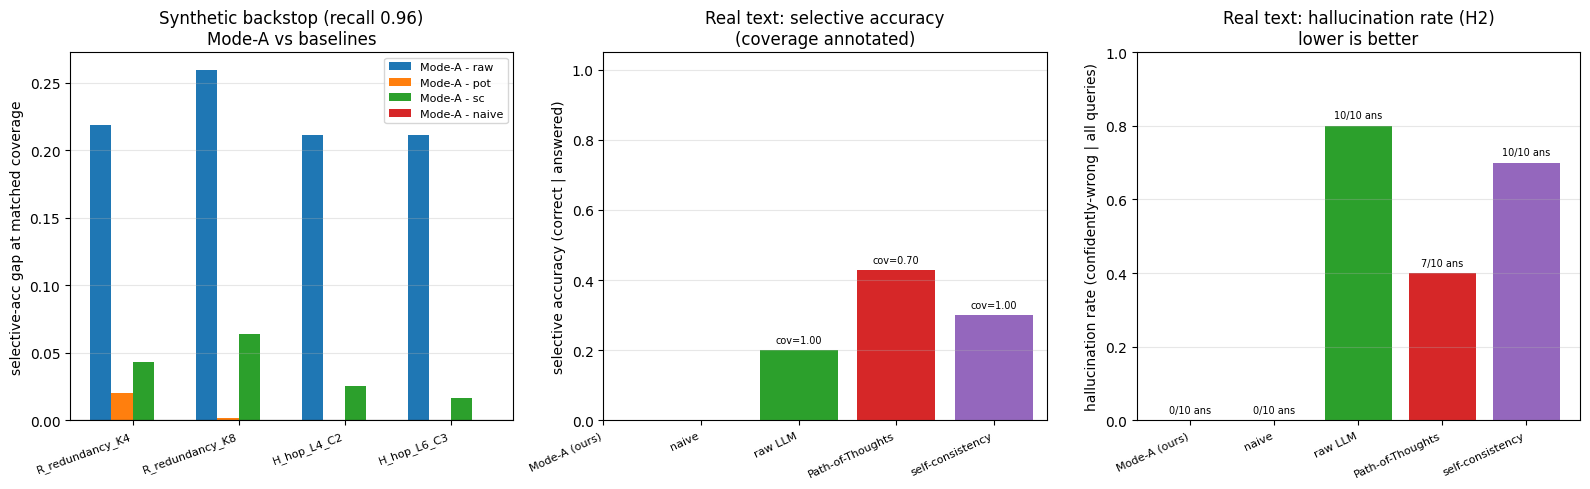


Takeaway:
  * Stage-0 closure tests pass -> closure outputs are sound certificates (THEOREM).
  * Synthetic backstop (recall 0.96): Mode-A beats raw/SC and ties naive on length-2,
    and naive/PoT cannot even reach Mode-A's coverage in the hop family (SYNTHETIC-CHANNEL).
  * Worked Prolog traces: Mode-A narrows to the correct singleton; collapse -> Mode-B abstain.
  * Real text: Mode-A drives the confident-wrong (hallucination) rate toward 0 by abstaining
    instead of fabricating (REAL-LLM-READ).


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- (1) synthetic matched-coverage gaps ---
ax = axes[0]
cells = list(synth.keys())
bases = ["raw", "pot", "sc", "naive"]
x = np.arange(len(cells)); w = 0.2
for bi, base in enumerate(bases):
    gaps = [(synth[c]["vs_baselines"][base]["gap"]
             if synth[c]["vs_baselines"][base]["gap"] == synth[c]["vs_baselines"][base]["gap"]
             else 0.0) for c in cells]
    ax.bar(x + bi * w, gaps, w, label=f"Mode-A - {base}")
ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(cells, rotation=20, fontsize=8, ha="right")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("selective-acc gap at matched coverage")
ax.set_title(f"Synthetic backstop (recall {SYNTH_RECALL})\nMode-A vs baselines")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

# --- (2) real-text selective accuracy ---
ax = axes[1]
labels = [r["method"] for r in rows]
accs = [r["selective_acc"] for r in rows]
covs = [r["coverage"] for r in rows]
bars = ax.bar(range(len(labels)), accs, color=["C0", "C1", "C2", "C3", "C4"])
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=25, fontsize=8, ha="right")
ax.set_ylabel("selective accuracy (correct | answered)")
ax.set_ylim(0, 1.05)
ax.set_title("Real text: selective accuracy\n(coverage annotated)")
for i, (b, cov) in enumerate(zip(bars, covs)):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
            f"cov={cov:.2f}", ha="center", fontsize=7)
ax.grid(alpha=0.3, axis="y")

# --- (3) real-text end-to-end hallucination rate (H2) ---
ax = axes[2]
halluc = [r["halluc_rate"] for r in rows]
bars = ax.bar(range(len(labels)), halluc, color=["C0", "C1", "C2", "C3", "C4"])
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=25, fontsize=8, ha="right")
ax.set_ylabel("hallucination rate (confidently-wrong | all queries)")
ax.set_ylim(0, max(1.0, max(halluc) * 1.15 if halluc else 1.0))
ax.set_title("Real text: hallucination rate (H2)\nlower is better")
for i, (b, r) in enumerate(zip(bars, rows)):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
            f"{r['answered']}/{r['n_queries']} ans", ha="center", fontsize=7)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\nTakeaway:")
print("  * Stage-0 closure tests pass -> closure outputs are sound certificates (THEOREM).")
print("  * Synthetic backstop (recall 0.96): Mode-A beats raw/SC and ties naive on length-2,")
print("    and naive/PoT cannot even reach Mode-A's coverage in the hop family (SYNTHETIC-CHANNEL).")
print("  * Worked Prolog traces: Mode-A narrows to the correct singleton; collapse -> Mode-B abstain.")
print("  * Real text: Mode-A drives the confident-wrong (hallucination) rate toward 0 by abstaining")
print("    instead of fabricating (REAL-LLM-READ).")